<a href="https://colab.research.google.com/github/GGPwis/Aprendizaje-Automatico/blob/main/TP2_AA1_regresion_lineal_redes_Portal_gustavo_Gabriel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 AA1
- **Nombre y Apellido: Gustavo Gabriel Portal**
- **Carrera: Cs de Datos e IA**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



# RESOLUCIÓN:

## A) Descripcion del Dataset: 📊

### Nombre del Dataset:
Real  Estate Valuation Data Set (Valoracion de vienes y raices)
### Fuente:
https://archive.ics.uci.edu/ml/datasets/Real+estate+valuation+data+set
### Descripcion general:
Este conjunto de datos se centra en la valoración de bienes raíces en la ciudad de Taipéi (Taiwán). Contiene información sobre distintos factores que influyen en el precio de las viviendas, como la edad del edificio, la distancia al transporte público, el número de tiendas cercanas y la ubicación geográfica. Posee en total 414 registros y 7 columnas (sin contar con el numero de registro) todas numericas, las cuales se describen a continuacion:

`No`: numero de registro.

`X1 transaccion date`: fecha de transaccion.

`X2 House Age`: antiguedad de la vivienda.

`X3 distance to the nearest MRT station`: distancia al sistema de metros.

`X4 numero de tiendas de conveniencia`: numero de tiendas de conveniencias cercanas.

`X5 latitud`: latitud de la propiedad.

`X6 longitud`: longitud de la propiedad.

`Y precio de la propiedad`: precio del inmueble (target).

## B) Importacion del dataset: 🌩

In [2]:
# Importamos las bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Configuramos visualizaciones más atractivas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

# Importamos módulos específicos de scikit-learn para preprocesamiento
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

# Para detectar outliers
from sklearn.ensemble import IsolationForest

# Para verificar el rendimiento de nuestros modelos
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Algunos modelos sencillos para demostrar el impacto del preprocesamiento
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para evitar warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Descarga y carga del dataset desde UCI Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00477/Real%20estate%20valuation%20data%20set.xlsx'
df = pd.read_excel(url)
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
# Renombrar las variables a español.
df_esp = [
    "id",
    "fecha_transaccion",
    "edad_casa",
    "distancia_MRT",
    "num_tiendas",
    "latitud",
    "longitud",
    "precio_vivienda"]
df.columns = df_esp
df.head()

,id,fecha_transaccion,edad_casa,distancia_MRT,num_tiendas,latitud,longitud,precio_vivienda
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
# Valores nulos
df.isnull().sum()
print(f'Número de valores nulos:\n {df.isnull().sum()}')

Número de valores nulos:
 id                   0
fecha_transaccion    0
edad_casa            0
distancia_MRT        0
num_tiendas          0
latitud              0
longitud             0
precio_vivienda      0
dtype: int64


In [6]:
df.duplicated().sum()
print(f'Numero de filas duplicadas: {df.duplicated().sum()}')

Numero de filas duplicadas: 0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 414 non-null    int64  
 1   fecha_transaccion  414 non-null    float64
 2   edad_casa          414 non-null    float64
 3   distancia_MRT      414 non-null    float64
 4   num_tiendas        414 non-null    int64  
 5   latitud            414 non-null    float64
 6   longitud           414 non-null    float64
 7   precio_vivienda    414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


### 2.1 Estadisticos principales

In [8]:
df.describe()

,id,fecha_transaccion,edad_casa,distancia_MRT,num_tiendas,latitud,longitud,precio_vivienda
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


Al observar los principales estadísticos del dataset, podemos inferir que no posee valores nulos y que todas las columnas son de tipo numérico. La variable `id` no es necesaria para el análisis, ya que se trata de un simple contador. Además, las variables se encuentran en distintas unidades de medida (por ejemplo, años para la edad de la casa, metros para la distancia al MRT y grados para las coordenadas geográficas), lo que sugiere la necesidad de normalización. También se observa una alta dispersión en variables como la edad de las casas, la distancia a la estación MRT y el precio de la vivienda, lo que podría indicar la presencia de outliers que afecten el rendimiento del modelo de regresión.

### 2.2 Grafico de Histograma:

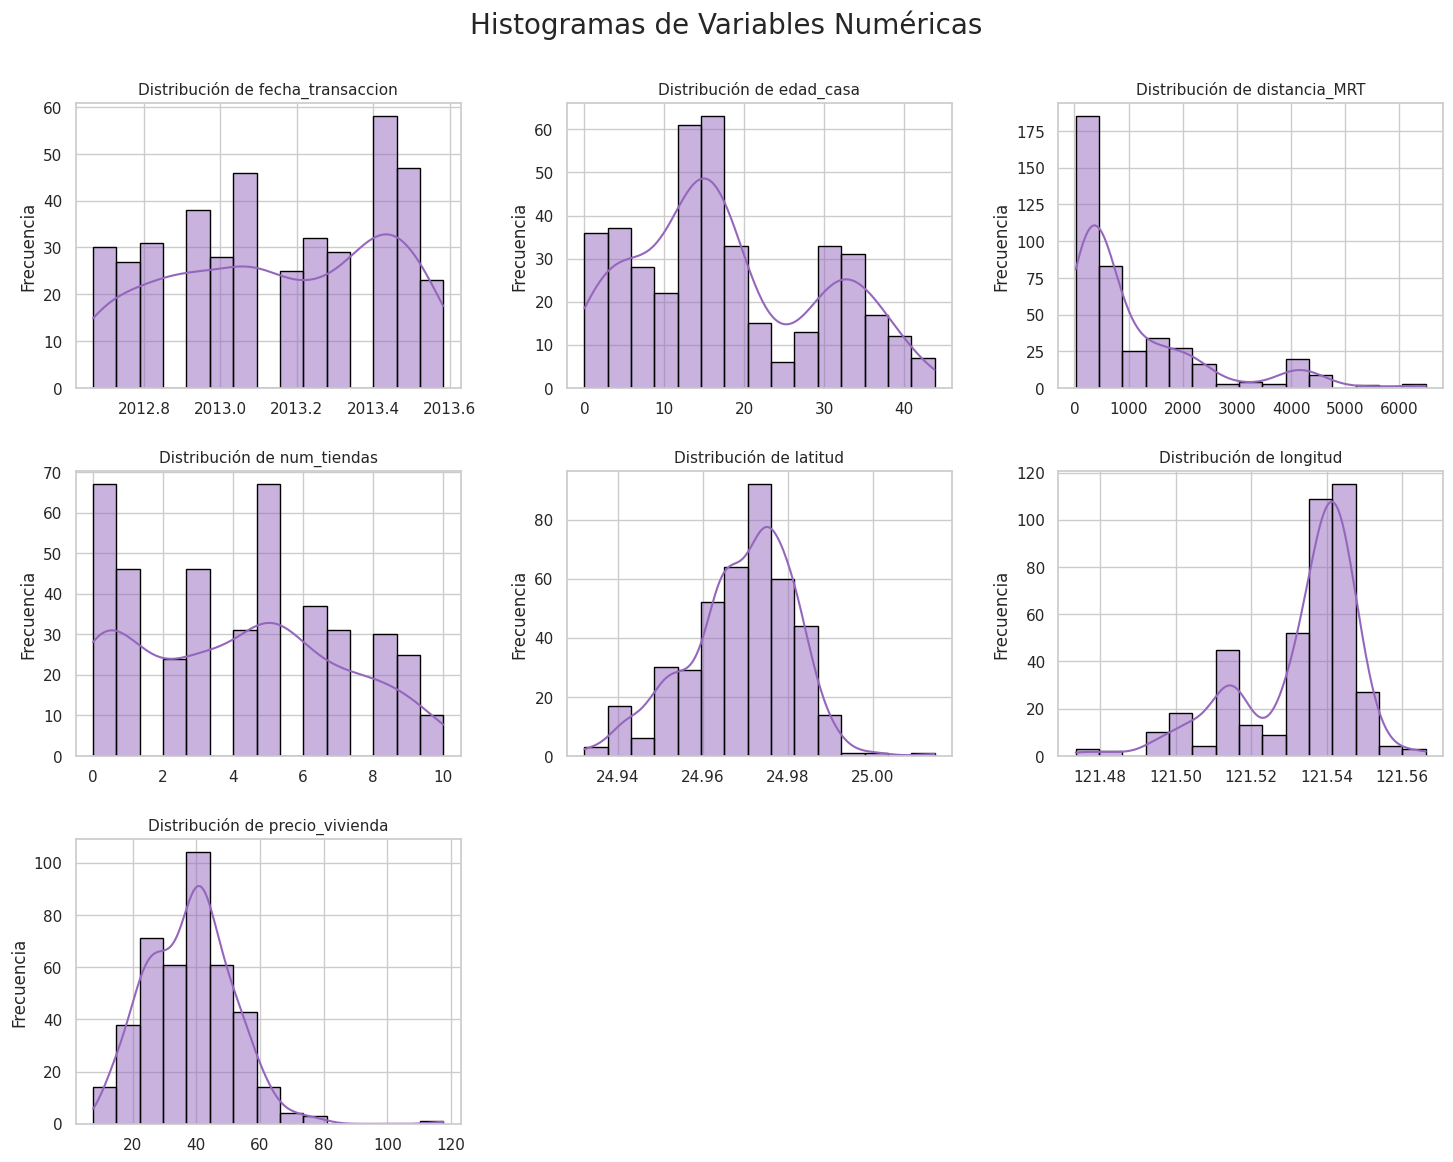

In [9]:
# Definir las variables para graficar
variables = ['fecha_transaccion', 'edad_casa', 'distancia_MRT',
              'num_tiendas', 'latitud', 'longitud', 'precio_vivienda']

# Crear la figura general
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Histograma + curva KDE por variable
for i, col in enumerate(variables):
    sns.histplot(df[col], bins=15, kde=True, ax=axes[i], color='#9467bd', edgecolor='black')
    axes[i].set_title(f'Distribución de {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# Eliminar ejes vacios
for i in range(len(variables), len(axes)):
    fig.delaxes(axes[i])

# Título general
fig.suptitle('Histogramas de Variables Numéricas', fontsize=20)
plt.tight_layout(pad=2.0)
plt.show()



- Fecha de transacción: No se observa una tendencia clara, los datos se encuentran distribuidos de manera relativamente uniforme a lo largo del período 2012–2013.

- Edad de la casa: La mayoría de las viviendas tienen entre 0 y 20 años, lo que sugiere construcciones relativamente nuevas. Este factor podría influir positivamente en el precio de las propiedades.

- Distancia a la estación de metro: La distribución está fuertemente sesgada hacia la derecha, lo que indica que la mayoría de las propiedades se encuentran a poca distancia de una estación (entre 0 y 1000 metros). Esto sugiere una concentración de viviendas dentro del tejido urbano.

- Número de tiendas cercanas: Presenta una distribución bastante regular, lo que sugiere que las propiedades están ubicadas en zonas con distintos niveles de densidad comercial.

- Latitud y longitud: Ambas variables muestran distribuciones muy concentradas, lo que confirma que las propiedades pertenecen a una misma región geográfica y no están significativamente alejadas entre sí.

- Precio de la vivienda: La distribución se concentra en un rango medio de valores, aunque se observan algunos posibles outliers. Esto indica cierta homogeneidad en los precios, con algunos casos de propiedades más costosas.

### 2.3 Grafico de Dispercion

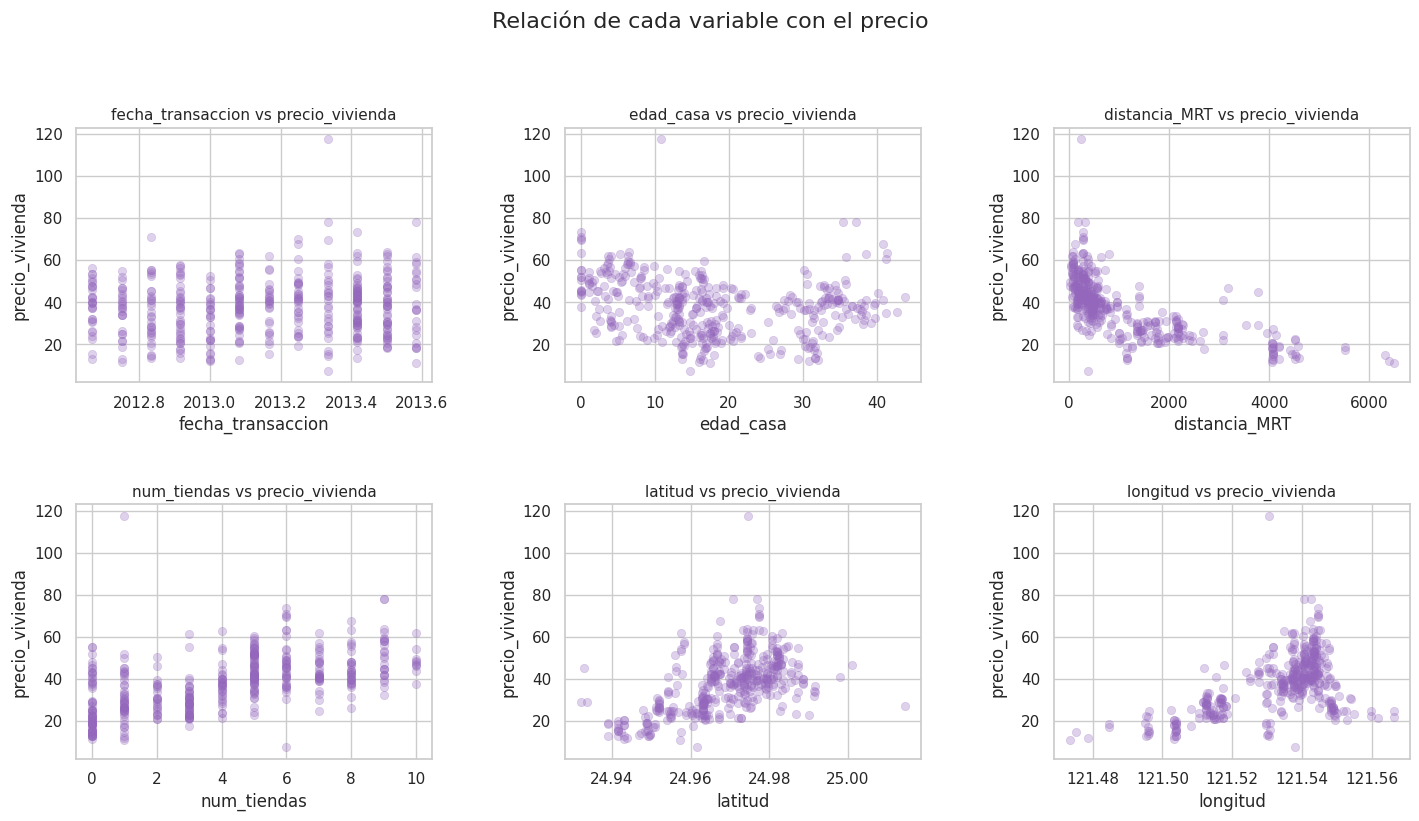

In [10]:
# Lista de variables predictoras
variables = ['fecha_transaccion', 'edad_casa', 'distancia_MRT',
              'num_tiendas', 'latitud', 'longitud']
target = 'precio_vivienda'

# Figura general fija (igual que el de histogramas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Scatter de cada variable contra el target
for i, col in enumerate(variables):
    sns.scatterplot(x=col, y=target, data=df, ax=axes[i],
                    color='#9467bd', alpha=0.3, edgecolor=None)
    axes[i].set_title(f'{col} vs {target}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

# Eliminar ejes vacíos si sobran
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Relación de cada variable con el precio', fontsize=16)
plt.tight_layout(pad=3.0)
plt.show()

### 2.4 Grafico de BoxPlots

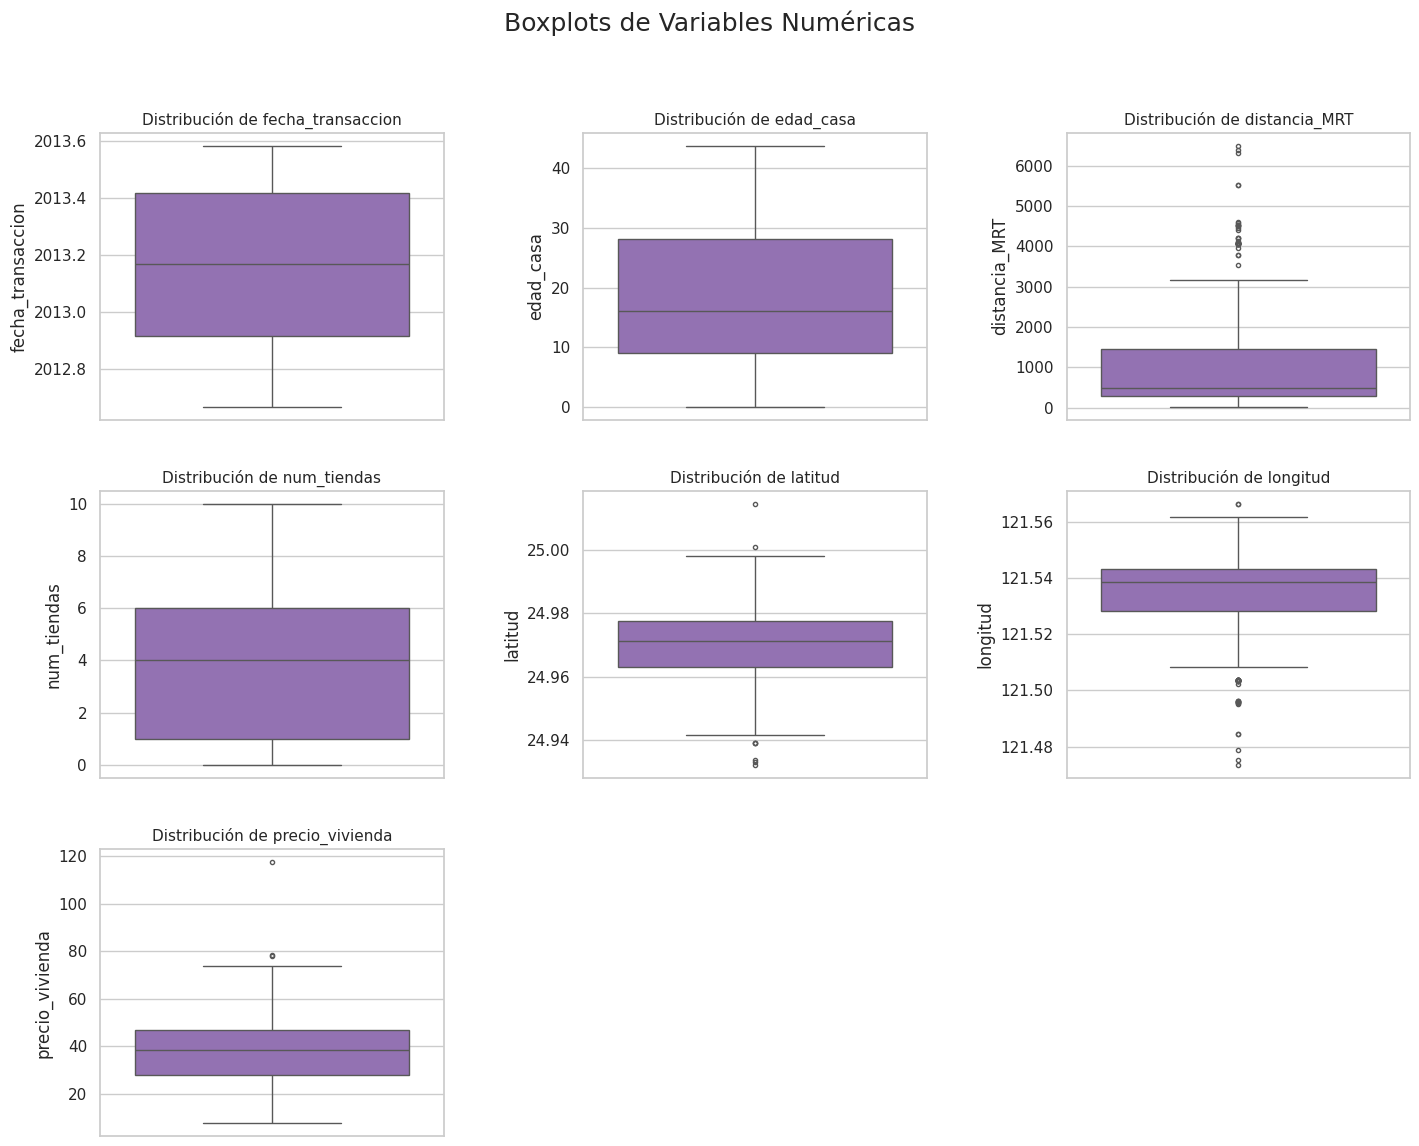

In [11]:
# Lista de variables numéricas
variables = ['fecha_transaccion', 'edad_casa', 'distancia_MRT',
              'num_tiendas', 'latitud', 'longitud', 'precio_vivienda']

# Crear figura general (3 filas, 3 columnas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Un boxplot por variable
for i, col in enumerate(variables):
    sns.boxplot(y=df[col], ax=axes[i], color='#9467bd', fliersize=3)
    axes[i].set_title(f'Distribución de {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Eliminar ejes vacíos si sobran
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

# Título general
fig.suptitle('Boxplots de Variables Numéricas', fontsize=18)
plt.tight_layout(pad=3.0)
plt.show()

Al observar los gráficos de boxplots, se puede apreciar la presencia de outliers en algunas variables, especialmente en precio_vivienda, latitud, longitud y distancia_MRT, siendo esta última la que presenta la mayor cantidad de valores atípicos.

### 2.5 Matriz de Correlacion

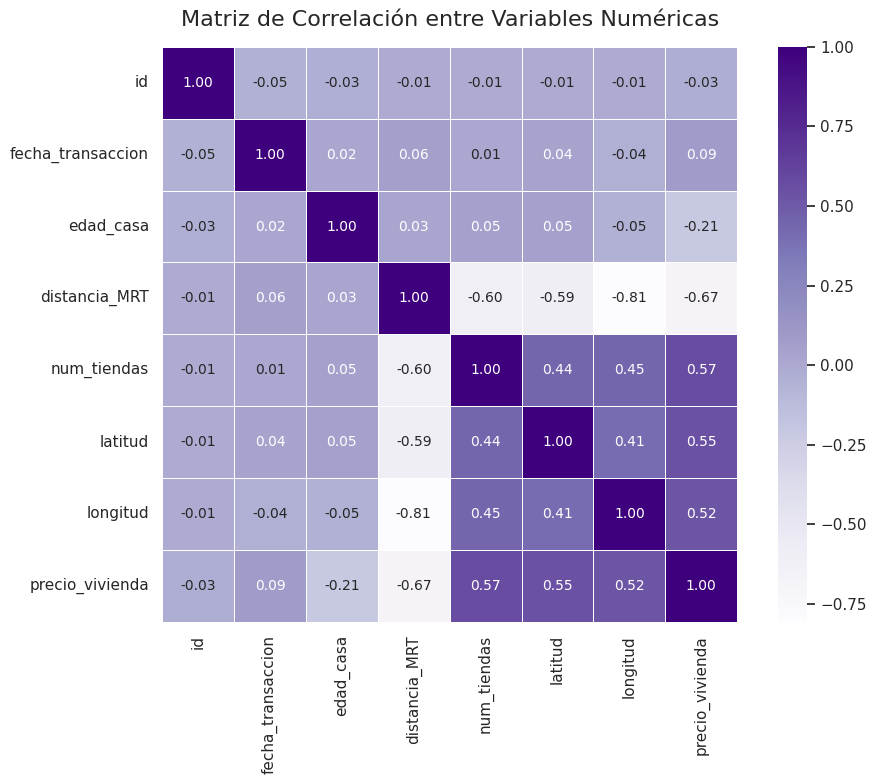

In [12]:
# Calcular la matriz de correlación
corr = df.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Purples', square=True, cbar=True,
            linewidths=0.5, annot_kws={"size": 10})

# Título
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

In [13]:
# Correlación con la variable objetivo (precio_vivienda)
correlations_with_target = corr['precio_vivienda'].sort_values(ascending=False)
print("Correlación de las variables con 'precio_vivienda':")
print(correlations_with_target)

Correlación de las variables con 'precio_vivienda':
precio_vivienda      1.000000
num_tiendas          0.571005
latitud              0.546307
longitud             0.523287
fecha_transaccion    0.087529
id                  -0.028587
edad_casa           -0.210567
distancia_MRT       -0.673613
Name: precio_vivienda, dtype: float64


Al observar la matriz de correlación y considerando nuestra variable objetivo (target), podemos inferir que la longitud, la latitud y el número de tiendas cercanas influyen positivamente en el precio de las viviendas, mientras que la distancia al metro y la antigüedad de la casa lo hacen de manera negativa.
Por otro lado, tanto la fecha de transacción como el identificador del registro (ID) presentan una correlación prácticamente nula con el precio, por lo que pueden considerarse variables irrelevantes para el modelo de regresión.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

In [14]:
# Copia del dataset original
df_prep = df.copy()

### 3.1 Eliminacion de variables

Eliminamos la columna `id` y la `fecha_transaccion` ya que no son necesaria para el modelo, ni para el analisis, la primera por ser solo un identificador de registro y la segunda por tener una correlacion cercana a 0 dando a entender que no es util como variable predictoria no afecta al precio de venta..

In [15]:
df_prep.drop(columns=['id', 'fecha_transaccion'], inplace=True)

In [16]:
df_prep.head()

,edad_casa,distancia_MRT,num_tiendas,latitud,longitud,precio_vivienda
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


### 3.2 Escalado Robusto:

A continuación, se aplicó un escalado robusto a las variables predictoras, ya que se encuentran en distintas unidades de medida.
La elección de este método se debe a que algunas variables presentan valores atípicos (outliers) y este tipo de escalado no es sensible a dichos valores, manteniendo la distribución original de los datos sin que los extremos influyan significativamente.

In [17]:
# Variables numéricas a escalar (todas las predictoras, sin incluir el target)
columnas_a_escalar = ['edad_casa', 'distancia_MRT', 'num_tiendas', 'latitud', 'longitud']

# Crear y aplicar el escalador
scaler = RobustScaler()
df_prep[columnas_a_escalar] = scaler.fit_transform(df_prep[columnas_a_escalar])

# Verificar que el escalado se haya aplicado correctamente
print("Estadísticas descriptivas después del escalado robusto:\n")
df_prep.describe().round(2)

Estadísticas descriptivas después del escalado robusto:



,edad_casa,distancia_MRT,num_tiendas,latitud,longitud,precio_vivienda
count,414.00,414.00,414.00,414.00,414.00,414.00
mean,0.08,0.51,0.02,-0.14,-0.35,37.98
std,0.60,1.08,0.59,0.86,1.01,13.61
min,-0.84,-0.40,-0.80,-2.70,-4.28,7.60
25%,-0.37,-0.17,-0.60,-0.56,-0.69,27.70
50%,0.00,0.00,0.00,0.00,0.00,38.45
75%,0.63,0.83,0.40,0.44,0.31,46.60
max,1.45,5.15,1.20,3.01,1.82,117.50





## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


### 4.1 Ajuste del Modelo

In [18]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df_prep.drop('precio_vivienda', axis=1)
y = df_prep['precio_vivienda']

# Dividir datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos un objeto de la clase LinearRegression
reg_mul = linear_model.LinearRegression()

# Entrenamos el modelo pasandole las variables independientes y dependiente
reg_mul.fit(X_train, y_train)

LinearRegression()

### 4.2 Prueba con los datos de entrenamiento

In [19]:
# Obtenemos las predicciones del modelo con los datos de entrenamiento
y_predict = reg_mul.predict(X_train)

# Calculamos los errores
mae_train = mean_absolute_error(y_true=y_train, y_pred=y_predict)
mse_train = mean_squared_error(y_true=y_train, y_pred=y_predict)
rmse_train=math.sqrt(mse_train)

print("===ERRORES EN LOS DATOS DE ENTRENAMIENTO===\n")
print("Error Absoluto Medio (MAE): {error}".format(error=mae_train))
print("Error Cuadrático Medio (MSE): {error}".format(error=mse_train))
print("Raiz del Error Cuadrático Medio (RMSE): {error}".format(error=rmse_train))

===ERRORES EN LOS DATOS DE ENTRENAMIENTO===

Error Absoluto Medio (MAE): 6.3902284223131405
Error Cuadrático Medio (MSE): 85.43289947763147
Raiz del Error Cuadrático Medio (RMSE): 9.24299191158531


### 4.2 Prueba con los datos de test

In [20]:
# Obtenemos las predicciones del modelo con los datos de test
y_predict = reg_mul.predict(X_test)

# Calculamos los errores
mae_test = mean_absolute_error(y_true=y_test, y_pred=y_predict)
mse_test = mean_squared_error(y_true=y_test, y_pred=y_predict)
rmse_test=math.sqrt(mse_test)

print("===ERRORES EN LOS DATOS DE TESTEO===\n")
print("Error Absoluto Medio (MAE): {error}".format(error=mae_test))
print("Error Cuadrático Medio (MSE): {error}".format(error=mse_test))
print("Raiz del Error Cuadrático Medio (RMSE): {error}".format(error=rmse_test))

===ERRORES EN LOS DATOS DE TESTEO===

Error Absoluto Medio (MAE): 5.350138374356213
Error Cuadrático Medio (MSE): 54.5809452008621
Raiz del Error Cuadrático Medio (RMSE): 7.387891796775458


### 4.3 Comparacion de metricas

In [21]:
# ========== MÉTRICAS REDONDEADAS ==========

# Entrenamiento
mae_train_round = round(mae_train, 2)
mse_train_round = round(mse_train, 2)
rmse_train_round = round(rmse_train, 2)

# Test
mae_test_round = round(mae_test, 2)
mse_test_round = round(mse_test, 2)
rmse_test_round = round(rmse_test, 2)

# ========== TABLA COMPARATIVA ==========
print("=" * 60)
print("COMPARACIÓN DE MÉTRICAS: ENTRENAMIENTO vs TEST")
print("=" * 60)
print(f"{'Métrica':<20} {'Entrenamiento':<20} {'Test':<20}")
print("-" * 60)
print(f"{'MAE':<20} {mae_train_round:<20} {mae_test_round:<20}")
print(f"{'MSE':<20} {mse_train_round:<20} {mse_test_round:<20}")
print(f"{'RMSE':<20} {rmse_train_round:<20} {rmse_test_round:<20}")
print("=" * 60)

# ========== ANÁLISIS DE DIFERENCIAS ==========
print("\nDIFERENCIAS (Train - Test):")
print("-" * 60)
diff_mae = round(mae_train - mae_test, 2)
diff_mse = round(mse_train - mse_test, 2)
diff_rmse = round(rmse_train - rmse_test, 2)

print(f"Diferencia MAE:  {diff_mae:>8} {'(mejor en test ✓)' if diff_mae > 0 else '(mejor en train)'}")
print(f"Diferencia MSE:  {diff_mse:>8} {'(mejor en test ✓)' if diff_mse > 0 else '(mejor en train)'}")
print(f"Diferencia RMSE: {diff_rmse:>8} {'(mejor en test ✓)' if diff_rmse > 0 else '(mejor en train)'}")
print("=" * 60)
print('\n Tabla Generada con CLAUDE AI')

COMPARACIÓN DE MÉTRICAS: ENTRENAMIENTO vs TEST
Métrica              Entrenamiento        Test                
------------------------------------------------------------
MAE                  6.39                 5.35                
MSE                  85.43                54.58               
RMSE                 9.24                 7.39                

DIFERENCIAS (Train - Test):
------------------------------------------------------------
Diferencia MAE:      1.04 (mejor en test ✓)
Diferencia MSE:     30.85 (mejor en test ✓)
Diferencia RMSE:     1.86 (mejor en test ✓)

 Tabla Generada con CLAUDE AI


Se observa que el modelo presenta un desempeño estable entre los conjuntos de entrenamiento y prueba. Los errores (MAE, MSE y RMSE) son incluso ligeramente menores en el conjunto de test, lo que indica que el modelo no está sobreajustado y generaliza correctamente.

### 4.4 R² Coeficiente de Determinacion

In [22]:
y_pred_train = reg_mul.predict(X_train)
y_pred_test = reg_mul.predict(X_test)

# R² para entrenamiento
r2_train = r2_score(y_train, y_pred_train)
print(f"\nR² (train): {r2_train:.4f}")

# R² para test
r2_test = r2_score(y_test, y_pred_test)
print(f"R² (test): {r2_test:.4f}")

print(f"\n El modelo explica el {r2_train*100:.2f}% de la variabilidad en entrenamiento")
print(f" El modelo explica el {r2_test*100:.2f}% de la variabilidad en test")


R² (train): 0.5458
R² (test): 0.6746

 El modelo explica el 54.58% de la variabilidad en entrenamiento
 El modelo explica el 67.46% de la variabilidad en test


- R² en entrenamiento (54.58%): El modelo explica poco más de la mitad de la variabilidad en los datos de entrenamiento. Es un ajuste moderado, deja 45% de "ruido".

- R² en test (67.46%): Explica casi el 67% en datos no vistos, sugiere que el modelo generaliza bien, funciona mejor en test.


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



### 5.1 Coeficientes del modelo

In [23]:
# Coeficientes
reg_mul.coef_

array([-5.17509563, -5.30344935,  5.52560395,  3.41272187, -0.36381423])

In [24]:
# Mostrar nombre + coeficiente del modelo
features = ['edad_casa', 'distancia_MRT', 'num_tiendas', 'latitud', 'longitud']

print("===Coeficientes e intecepto del modelo===\n")
for i in range(len(features)):
    print(features[i], ":", round(reg_mul.coef_[i], 4))
print('\n','-'*40)
# Intercepto
print("\nIntercepto:", round(reg_mul.intercept_, 4))


===Coeficientes e intecepto del modelo===

edad_casa : -5.1751
distancia_MRT : -5.3034
num_tiendas : 5.5256
latitud : 3.4127
longitud : -0.3638

 ----------------------------------------

Intercepto: 41.4396


### 5.2 Interpretacion de los coeficientes e intecepto:

- `edad_casa`: presenta un efecto negativo sobre el precio del inmueble, lo que sugiere que, a medida que la vivienda es más antigua, su valor tiende a disminuir

- `distancia_MRT`: es el coeficiente con mayor peso dentro del modelo, por lo tanto, tiene la mayor influencia sobre el precio. Las viviendas ubicadas más lejos de las estaciones de metro tienden a perder valor.

- `num_tiendas`: es el coeficiente positivo más alto. Esto indica que los inmuebles situados en zonas con mayor cantidad de tiendas o comercios cercanos tienden a tener un precio más elevado.

- `latitud`: muestra un coeficiente positivo, lo que sugiere que ciertas áreas geográficas presentan precios más altos.

- `longitud`: presenta un coeficiente negativo de baja magnitud, lo que implica que la ubicación de los inmuebles en ese eje no tiene un impacto significativo sobre el precio..

- **intercepto:** el promedio del precio base de una propiedad, cuando todas las demas variables predictorias son cero.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



### 6.1 ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?

Las variables más importantes para el modelo son la edad de la casa, la distancia al metro (MRT) y el número de tiendas cercanas, ya que son las que presentan los coeficientes de mayor magnitud, tanto en sentido positivo como negativo. Esto indica que son las que más influyen en el precio por unidad de área:

- A mayor antigüedad o distancia al metro, el valor del inmueble tiende a disminuir.
- A mayor cantidad de tiendas en la zona, el valor del inmueble aumenta.

En cuanto a la comparación con el análisis exploratorio, los resultados coinciden en gran medida.
En los histogramas, gráficos de dispersión y boxplots ya se observaban las mismas tendencias

### 6.2 ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?

El modelo no presenta sobreajuste, ya que el R² del entrenamiento (0.54) y el del test (0.67) son similares. Esto indica que generaliza bien y logra explicar una parte importante de la variabilidad del precio por unidad de área.
Sin embargo, su rendimiento podría mejorar si el dataset incluyera más variables relevantes que influyen en el valor de una propiedad, como la calidad de la construcción, la zona, el acceso a servicios, o la infraestructura del entorno.



## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  

In [25]:
# Copia del dataset original
df_bonus = df.copy()
df_bonus.drop(columns=['id', 'fecha_transaccion', 'latitud', 'longitud'], inplace=True)

In [26]:
# Variables numéricas a escalar (todas las predictoras, sin incluir el target)
columnas_a_escalar_bonus = ['edad_casa', 'distancia_MRT', 'num_tiendas']

# Crear y aplicar el escalador
scaler = RobustScaler()
df_bonus[columnas_a_escalar_bonus] = scaler.fit_transform(df_bonus[columnas_a_escalar_bonus])

# Verificar que el escalado se haya aplicado correctamente
print("Estadísticas descriptivas después del escalado robusto:\n")
df_bonus.describe().round(2)

Estadísticas descriptivas después del escalado robusto:



,edad_casa,distancia_MRT,num_tiendas,precio_vivienda
count,414.00,414.00,414.00,414.00
mean,0.08,0.51,0.02,37.98
std,0.60,1.08,0.59,13.61
min,-0.84,-0.40,-0.80,7.60
25%,-0.37,-0.17,-0.60,27.70
50%,0.00,0.00,0.00,38.45
75%,0.63,0.83,0.40,46.60
max,1.45,5.15,1.20,117.50


In [27]:
# Separar variables predictoras (X) y variable objetivo (y)
Xb = df_bonus.drop('precio_vivienda', axis=1)
yb = df_bonus['precio_vivienda']

# Dividir datos: 80% entrenamiento, 20% prueba
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(Xb, yb, test_size=0.2, random_state=1)

# Creamos un objeto de la clase LinearRegression
reg_bonus = linear_model.LinearRegression()

# Entrenamos el modelo pasandole las variables independientes y dependiente
reg_bonus.fit(X_train_b, y_train_b)

LinearRegression()

In [28]:
# Obtenemos las predicciones del modelo con los datos de entrenamiento
y_predict_b = reg_bonus.predict(X_train_b)

# Calculamos los errores
mae_train_b = mean_absolute_error(y_true=y_train_b, y_pred=y_predict_b)
mse_train_b = mean_squared_error(y_true=y_train_b, y_pred=y_predict_b)
rmse_train_b=math.sqrt(mse_train_b)

print("===ERRORES EN LOS DATOS DE ENTRENAMIENTO===\n")
print("Error Absoluto Medio (MAE): {error}".format(error=mae_train_b))
print("Error Cuadrático Medio (MSE): {error}".format(error=mse_train_b))
print("Raiz del Error Cuadrático Medio (RMSE): {error}".format(error=rmse_train_b))

===ERRORES EN LOS DATOS DE ENTRENAMIENTO===

Error Absoluto Medio (MAE): 6.846065537450915
Error Cuadrático Medio (MSE): 94.23843399403674
Raiz del Error Cuadrático Medio (RMSE): 9.707648221584709


In [29]:
# Obtenemos las predicciones del modelo con los datos de test
y_predict_b = reg_bonus.predict(X_test_b)

# Calculamos los errores
mae_test_b = mean_absolute_error(y_true=y_test_b, y_pred=y_predict_b)
mse_test_b = mean_squared_error(y_true=y_test_b, y_pred=y_predict_b)
rmse_test_b=math.sqrt(mse_test_b)

print("===ERRORES EN LOS DATOS DE TESTEO===\n")
print("Error Absoluto Medio (MAE): {error}".format(error=mae_test_b))
print("Error Cuadrático Medio (MSE): {error}".format(error=mse_test_b))
print("Raiz del Error Cuadrático Medio (RMSE): {error}".format(error=rmse_test_b))

===ERRORES EN LOS DATOS DE TESTEO===

Error Absoluto Medio (MAE): 5.475527486473667
Error Cuadrático Medio (MSE): 48.35356448982548
Raiz del Error Cuadrático Medio (RMSE): 6.953672733874199


In [30]:
# Coeficientes de determinacion bonus
y_pred_train_b = reg_bonus.predict(X_train_b)
y_pred_test_b = reg_bonus.predict(X_test_b)

# R² para entrenamiento
r2_train_b = r2_score(y_train_b, y_pred_train_b)
print(f"\nR² bonus (train): {r2_train_b:.4f}")

# R² para test
r2_test_b = r2_score(y_test_b, y_pred_test_b)
print(f"R² bonus (test): {r2_test_b:.4f}")

print(f"\n El modelo explica el {r2_train_b*100:.2f}% de la variabilidad en entrenamiento")
print(f" El modelo explica el {r2_test_b*100:.2f}% de la variabilidad en test")


R² bonus (train): 0.5047
R² bonus (test): 0.6814

 El modelo explica el 50.47% de la variabilidad en entrenamiento
 El modelo explica el 68.14% de la variabilidad en test


In [31]:
print("===Comparativa modelo principal vs bonus===\n")
print("Modelo Principal:")
print(f"R² (train): {r2_train:.4f}")
print(f"R² (test): {r2_test:.4f}")
print(f"\n El modelo explica el {r2_train*100:.2f}% de la variabilidad en entrenamiento")
print(f" El modelo explica el {r2_test*100:.2f}% de la variabilidad en test")
print("\nModelo Bonus:")
print(f"R² (train): {r2_train_b:.4f}")
print(f"R² (test): {r2_test_b:.4f}")
print(f"\n El modelo explica el {r2_train_b*100:.2f}% de la variabilidad en entrenamiento")
print(f" El modelo explica el {r2_test_b*100:.2f}% de la variabilidad en test")


===Comparativa modelo principal vs bonus===

Modelo Principal:
R² (train): 0.5458
R² (test): 0.6746

 El modelo explica el 54.58% de la variabilidad en entrenamiento
 El modelo explica el 67.46% de la variabilidad en test

Modelo Bonus:
R² (train): 0.5047
R² (test): 0.6814

 El modelo explica el 50.47% de la variabilidad en entrenamiento
 El modelo explica el 68.14% de la variabilidad en test


# TP N 2 MPL + Regression

1ero) Debe realizar una copia de su TP1. Trabajará sobre ese mismo dataset.

2) Utilice redes neuronales para resolver el problema de regresión del dataset que Ud. trabajó en TP1.

Para ello debe:

- 2.1 Usar MLP con la librería MLP.

- 2.2 Presentar un caso donde la MLP sobreajuste.

- 2.3 Presentar un caso donde la MLP subajuste.

- 2.4 Presentar el caso donde cree que la MLP funciona de forma aceptable.

  Tanto para 2.2, 2.3 y 2.4 deberá entrenar un modelo de red neuronal multicapa (MLP) con diferentes configuraciones de hiperparámetros (modificar nro de neuronas en capas ocultas, nro de capas ocultas).

  Debe indicar las métricas de evaluación de los modelos e indicar como determina si sobreajusta (overfeatting) o si subajusta (underfitting)

- 2.5 Agregue sus conclusiones comparando la experiencia y resultados del modelo de regresión lineal con el modelo del punto 2.4)

## 2 Utilice redes neuronales para resolver el problema de regresión del dataset que Ud. trabajó en TP1.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

# Separar X e y
X = df_prep.drop('precio_vivienda', axis=1)
y = df_prep['precio_vivienda']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalar solo usando los datos de entrenamiento
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(X_train)

[[ 1.488      -0.37676747  0.6        -0.23606557  0.11002533]
 [-0.42133333  1.49477218  0.         -0.72327869 -1.85016287]
 [-0.46933333  1.458727   -0.2        -0.52786885 -1.92761491]
 ...
 [-0.272      -0.20773882 -0.6         0.2295082  -0.63047412]
 [-0.60266667 -0.20160285  0.4         0.31147541  0.43358668]
 [-0.78933333 -0.25888073  0.4        -0.35344262  0.12450235]]


### 2.1 Usar MLP con la librería MLP.

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

def train_and_evaluate(hidden_layer_sizes, max_iter=500, alpha=0.001):
    # Definición y entrenamiento
    mlp = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, alpha=alpha, random_state=42, activation='relu')
    mlp.fit(X_train, y_train)

    y_train_pred = mlp.predict(X_train)
    y_test_pred = mlp.predict(X_test)

    # 1. Métricas de Error
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    # 2. Métricas de Ajuste R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Devolvemos ambas métricas
    return mse_train, mse_test, r2_train, r2_test, mlp

### 2.1 Aplicacion de MPL

In [41]:
# BASE
mse_train_base, mse_test_base, r2_train_base, r2_test_base, mlp_base = train_and_evaluate(hidden_layer_sizes=(100,))
print("--- BASE ---")
print(f"R² Train: {r2_train_base:.4f} | R² Test: {r2_test_base:.4f}")
print(f"MSE Train: {mse_train_base:.4f} | MSE Test: {mse_test_base:.4f}\n")

--- BASE ---
R² Train: 0.6438 | R² Test: 0.7473
MSE Train: 67.0047 | MSE Test: 42.3854



#### Grafico MSE Base

BASE - hidden_layers=(5,), alpha=0.001
  - MSE entrenamiento: 1026.0571
  - MSE prueba: 905.3441

BASE - hidden_layers=(10,), alpha=0.001
  - MSE entrenamiento: 669.6279
  - MSE prueba: 573.4666

BASE - hidden_layers=(25,), alpha=0.001
  - MSE entrenamiento: 232.3219
  - MSE prueba: 221.3876

BASE - hidden_layers=(50,), alpha=0.001
  - MSE entrenamiento: 89.7580
  - MSE prueba: 62.6973

BASE - hidden_layers=(100,), alpha=0.001
  - MSE entrenamiento: 67.0047
  - MSE prueba: 42.3854



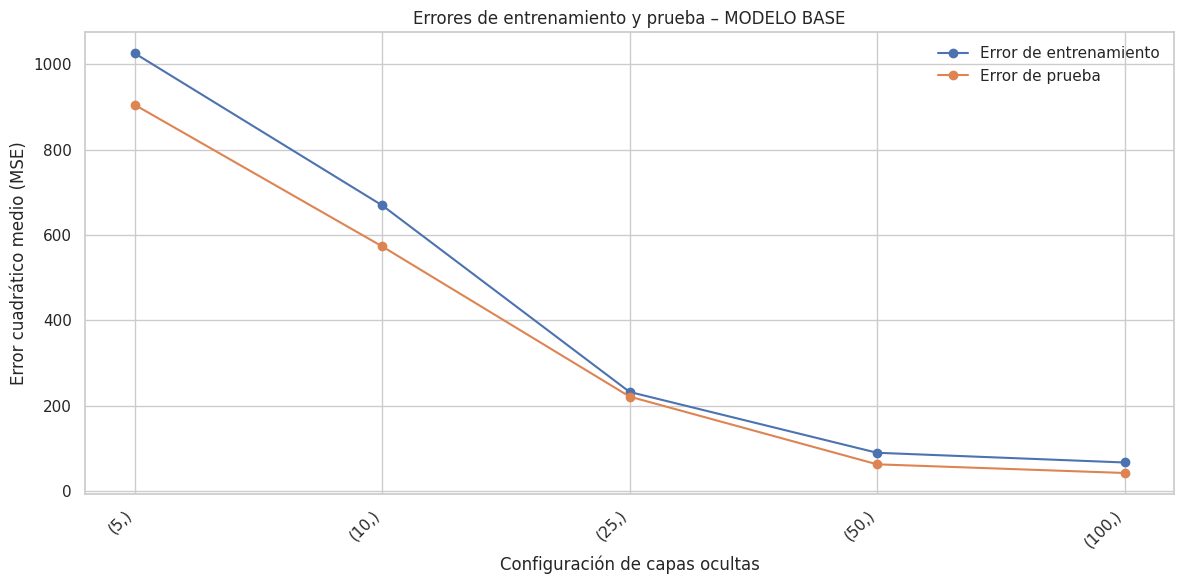

In [39]:
# GRAFICO BASE
hidden_layers_list = [(5,), (10,), (25,), (50,), (100,)]
alpha_value = 0.001

train_errors = []
test_errors = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=500)
    train_errors.append((hidden_layers, alpha_value, mse_train))
    test_errors.append((hidden_layers, alpha_value, mse_test))
    print(f"BASE - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - MSE entrenamiento: {mse_train:.4f}")
    print(f"  - MSE prueba: {mse_test:.4f}\n")

# Graficar
hidden_layer_labels = [f"{hl}" for hl, _, _ in train_errors]
train_error_values = [err for _, _, err in train_errors]
test_error_values = [err for _, _, err in test_errors]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, train_error_values, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Error cuadrático medio (MSE)')
plt.title('Errores de entrenamiento y prueba – MODELO BASE')
plt.legend()
plt.tight_layout()
plt.show()


#### Grafico R² Base

BASE - hidden_layers=(5,), alpha=0.001
  - R² entrenamiento: -4.4551
  - R² prueba: -4.3967

BASE - hidden_layers=(10,), alpha=0.001
  - R² entrenamiento: -2.5601
  - R² prueba: -2.4184

BASE - hidden_layers=(25,), alpha=0.001
  - R² entrenamiento: -0.2352
  - R² prueba: -0.3197

BASE - hidden_layers=(50,), alpha=0.001
  - R² entrenamiento: 0.5228
  - R² prueba: 0.6263

BASE - hidden_layers=(100,), alpha=0.001
  - R² entrenamiento: 0.6438
  - R² prueba: 0.7473



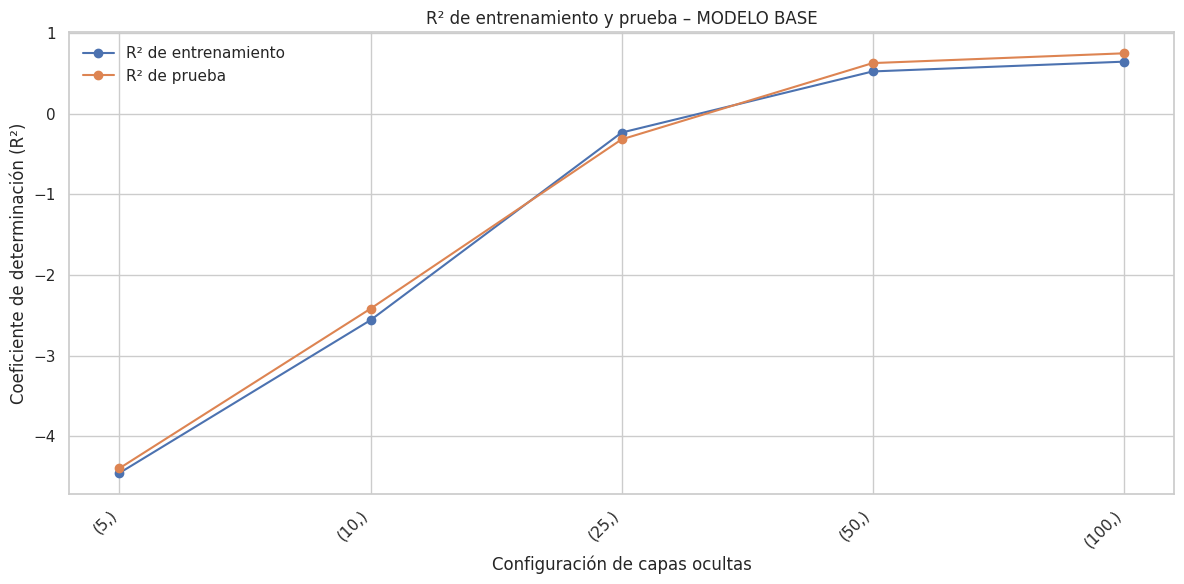

In [ ]:
# MODELO BASE - R²
hidden_layers_list = [(5,), (10,), (25,), (50,), (100,)]
alpha_value = 0.001

r2_train_scores = []
r2_test_scores = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=500)
    r2_train_scores.append((hidden_layers, alpha_value, r2_train))
    r2_test_scores.append((hidden_layers, alpha_value, r2_test))
    print(f"BASE - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - R² entrenamiento: {r2_train:.4f}")
    print(f"  - R² prueba: {r2_test:.4f}\n")

# Graficar R²
hidden_layer_labels = [f"{hl}" for hl, _, _ in r2_train_scores]
r2_train_values = [r2 for _, _, r2 in r2_train_scores]
r2_test_values = [r2 for _, _, r2 in r2_test_scores]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, r2_train_values, label='R² de entrenamiento', marker='o')
plt.plot(x, r2_test_values, label='R² de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Coeficiente de determinación (R²)')
plt.title('R² de entrenamiento y prueba – MODELO BASE')
plt.legend()
plt.tight_layout()
plt.show()


Para este modelo base, configurado con una red neuronal de 100 neuronas, una regularización de 0.001 y 500 iteraciones, se observa que tanto el error de entrenamiento como el de prueba son altos, aunque tienden a disminuir a medida que aumenta la cantidad de neuronas.
En cuanto al coeficiente de determinación (R²), los valores comienzan siendo negativos, pero aumentan progresivamente conforme se incrementa el número de neuronas.
Este modelo podría representar un caso de subajuste (underfitting), ya que logra explicar muy poca variabilidad de los datos y evidencia una capacidad de aprendizaje limitada.

### 2.2: Overfiting

In [ ]:
# OVERFITTING
mse_train_over, mse_test_over, r2_train_over, r2_test_over, mlp_over = train_and_evaluate(hidden_layer_sizes=(800,800,400), alpha=0.000001, max_iter=15000)
print("--- OVERFITTING ---")
print(f"R² Train: {r2_train_over:.4f} | R² Test: {r2_test_over:.4f}")
print(f"MSE Train: {mse_train_over:.4f} | MSE Test: {mse_test_over:.4f}\n")

--- OVERFITTING ---
R² Train: 0.8519 | R² Test: 0.7705
MSE Train: 27.8616 | MSE Test: 38.4969



#### Grafico MSE Overfitting

OVERFITTING - hidden_layers=(100,), alpha=1e-06
  - MSE entrenamiento: 49.3519
  - MSE prueba: 35.7741

OVERFITTING - hidden_layers=(200,), alpha=1e-06
  - MSE entrenamiento: 48.1431
  - MSE prueba: 34.5816

OVERFITTING - hidden_layers=(400,), alpha=1e-06
  - MSE entrenamiento: 47.8212
  - MSE prueba: 34.2948

OVERFITTING - hidden_layers=(800, 800, 400), alpha=1e-06
  - MSE entrenamiento: 27.8616
  - MSE prueba: 38.4969



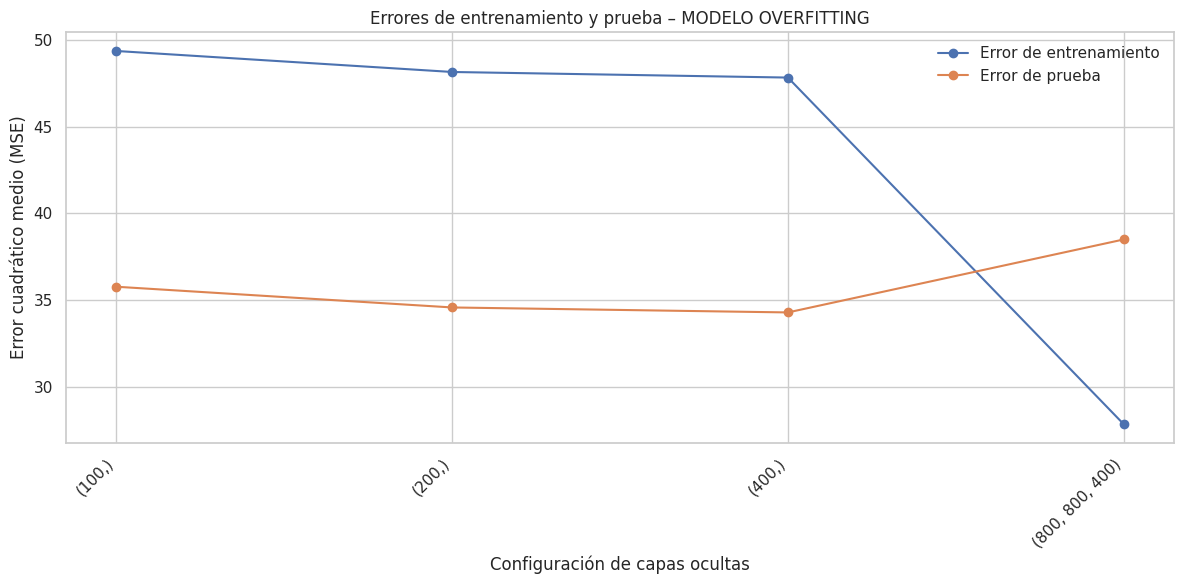

In [ ]:
# MODELO OVERFITTING
hidden_layers_list = [(100,), (200,), (400,), (800,800,400)]
alpha_value = 0.000001

train_errors = []
test_errors = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=15000)
    train_errors.append((hidden_layers, alpha_value, mse_train))
    test_errors.append((hidden_layers, alpha_value, mse_test))
    print(f"OVERFITTING - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - MSE entrenamiento: {mse_train:.4f}")
    print(f"  - MSE prueba: {mse_test:.4f}\n")

hidden_layer_labels = [f"{hl}" for hl, _, _ in train_errors]
train_error_values = [err for _, _, err in train_errors]
test_error_values = [err for _, _, err in test_errors]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, train_error_values, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Error cuadrático medio (MSE)')
plt.title('Errores de entrenamiento y prueba – MODELO OVERFITTING')
plt.legend()
plt.tight_layout()
plt.show()


#### Grafico R² Overfitting

OVERFITTING - hidden_layers=(100,), alpha=1e-06
  - R² entrenamiento: 0.7376
  - R² prueba: 0.7868

OVERFITTING - hidden_layers=(200,), alpha=1e-06
  - R² entrenamiento: 0.7440
  - R² prueba: 0.7939

OVERFITTING - hidden_layers=(400,), alpha=1e-06
  - R² entrenamiento: 0.7458
  - R² prueba: 0.7956

OVERFITTING - hidden_layers=(800, 800, 400), alpha=1e-06
  - R² entrenamiento: 0.8519
  - R² prueba: 0.7705



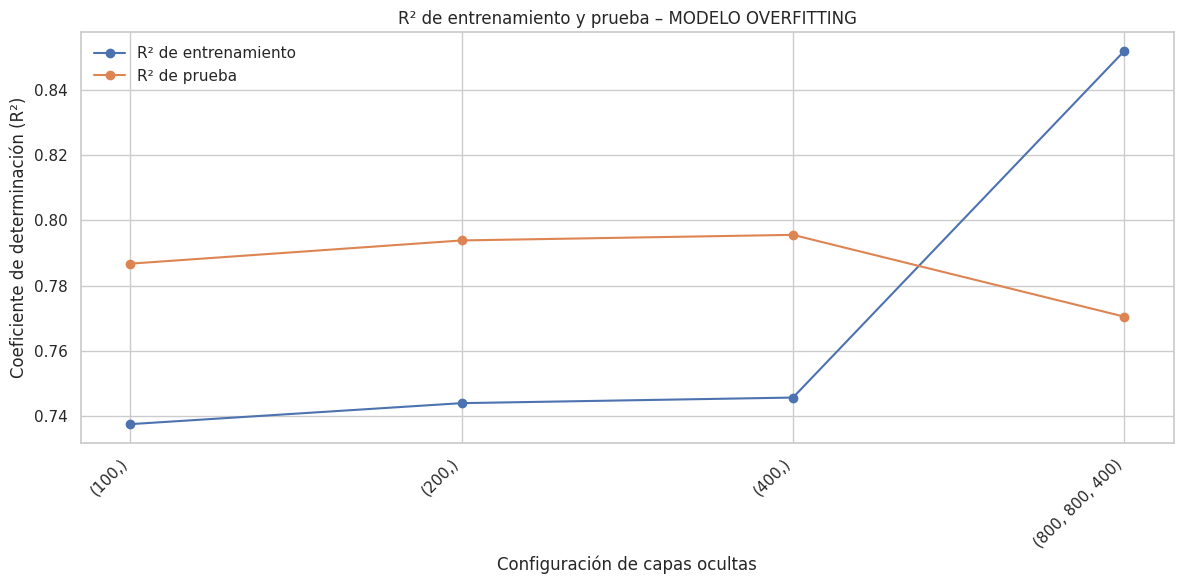

In [ ]:
# MODELO OVERFITTING – R²
hidden_layers_list = [(100,), (200,), (400,), (800,800,400)]
alpha_value = 0.000001

r2_train_scores = []
r2_test_scores = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=15000)
    r2_train_scores.append((hidden_layers, alpha_value, r2_train))
    r2_test_scores.append((hidden_layers, alpha_value, r2_test))
    print(f"OVERFITTING - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - R² entrenamiento: {r2_train:.4f}")
    print(f"  - R² prueba: {r2_test:.4f}\n")

hidden_layer_labels = [f"{hl}" for hl, _, _ in r2_train_scores]
r2_train_values = [r2 for _, _, r2 in r2_train_scores]
r2_test_values = [r2 for _, _, r2 in r2_test_scores]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, r2_train_values, label='R² de entrenamiento', marker='o')
plt.plot(x, r2_test_values, label='R² de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Coeficiente de determinación (R²)')
plt.title('R² de entrenamiento y prueba – MODELO OVERFITTING')
plt.legend()
plt.tight_layout()
plt.show()


Para provocar el overfitting, se decidió crear un modelo más complejo, con tres capas ocultas (800, 800 y 400 neuronas), una regularización extremadamente pequeña y 15.000 iteraciones.
En este caso, el error de entrenamiento disminuye drásticamente, mientras que el error de prueba tiende a aumentar, como puede observarse en el gráfico.
Esto sugiere que el modelo aprendió en exceso los patrones del conjunto de entrenamiento, perdiendo capacidad de generalización.
Algo similar ocurre con el coeficiente de determinación (R²): en entrenamiento tiende a elevarse, aparentando un excelente rendimiento, pero en el conjunto de prueba disminuye progresivamente, lo que confirma la pérdida de generalización característica del sobreajuste.

### 2.3 Underfiting

In [ ]:
# UNDERFITTING
mse_train_under, mse_test_under, r2_train_under, r2_test_under, mlp_under = train_and_evaluate(hidden_layer_sizes=(30,), alpha=0.01, max_iter=500)
print("--- UNDERFITTING ---")
print(f"R² Train: {r2_train_under:.4f} | R² Test: {r2_test_under:.4f}")
print(f"MSE Train: {mse_train_under:.4f} | MSE Test: {mse_test_under:.4f}\n")

--- UNDERFITTING ---
R² Train: 0.2218 | R² Test: 0.2356
MSE Train: 146.3653 | MSE Test: 128.2289



#### Grafico MSE Underfitting

UNDERFITTING - hidden_layers=(2,), alpha=0.01
  - MSE entrenamiento: 1478.9275
  - MSE prueba: 1322.0826

UNDERFITTING - hidden_layers=(5,), alpha=0.01
  - MSE entrenamiento: 1026.0560
  - MSE prueba: 905.3438

UNDERFITTING - hidden_layers=(10,), alpha=0.01
  - MSE entrenamiento: 669.6292
  - MSE prueba: 573.4694

UNDERFITTING - hidden_layers=(30,), alpha=0.01
  - MSE entrenamiento: 146.3653
  - MSE prueba: 128.2289



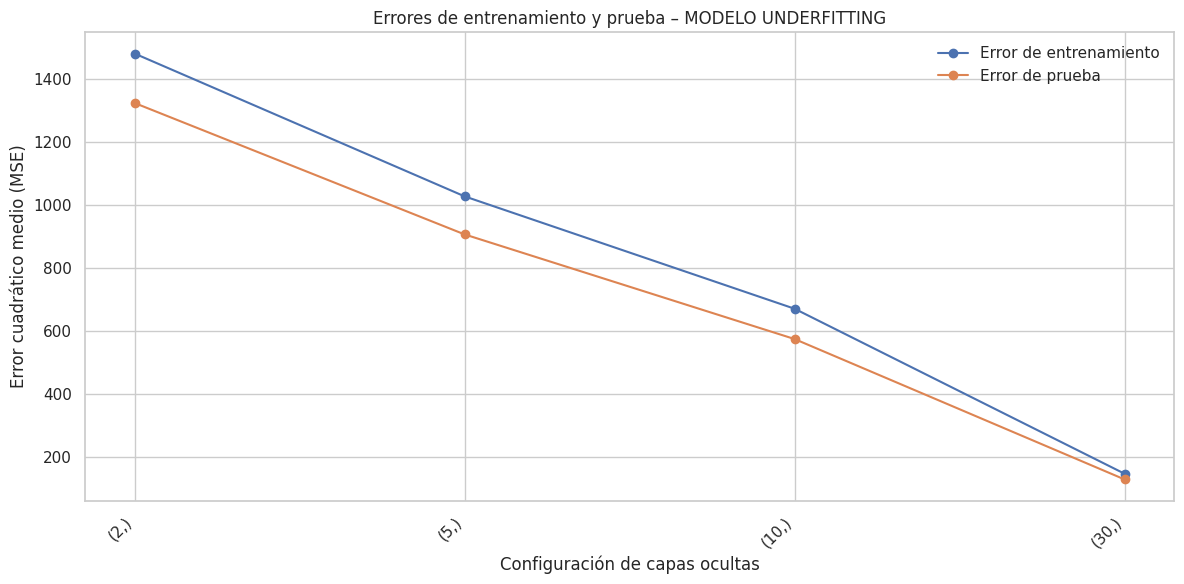

In [ ]:
# MODELO UNDERFITTING
hidden_layers_list = [(2,), (5,), (10,), (30,)]
alpha_value = 0.01

train_errors = []
test_errors = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=500)
    train_errors.append((hidden_layers, alpha_value, mse_train))
    test_errors.append((hidden_layers, alpha_value, mse_test))
    print(f"UNDERFITTING - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - MSE entrenamiento: {mse_train:.4f}")
    print(f"  - MSE prueba: {mse_test:.4f}\n")

hidden_layer_labels = [f"{hl}" for hl, _, _ in train_errors]
train_error_values = [err for _, _, err in train_errors]
test_error_values = [err for _, _, err in test_errors]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, train_error_values, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Error cuadrático medio (MSE)')
plt.title('Errores de entrenamiento y prueba – MODELO UNDERFITTING')
plt.legend()
plt.tight_layout()
plt.show()


#### Grafico R² Underfitting

UNDERFITTING - hidden_layers=(2,), alpha=0.01
  - R² entrenamiento: -6.8629
  - R² prueba: -6.8808

UNDERFITTING - hidden_layers=(5,), alpha=0.01
  - R² entrenamiento: -4.4551
  - R² prueba: -4.3967

UNDERFITTING - hidden_layers=(10,), alpha=0.01
  - R² entrenamiento: -2.5601
  - R² prueba: -2.4184

UNDERFITTING - hidden_layers=(30,), alpha=0.01
  - R² entrenamiento: 0.2218
  - R² prueba: 0.2356



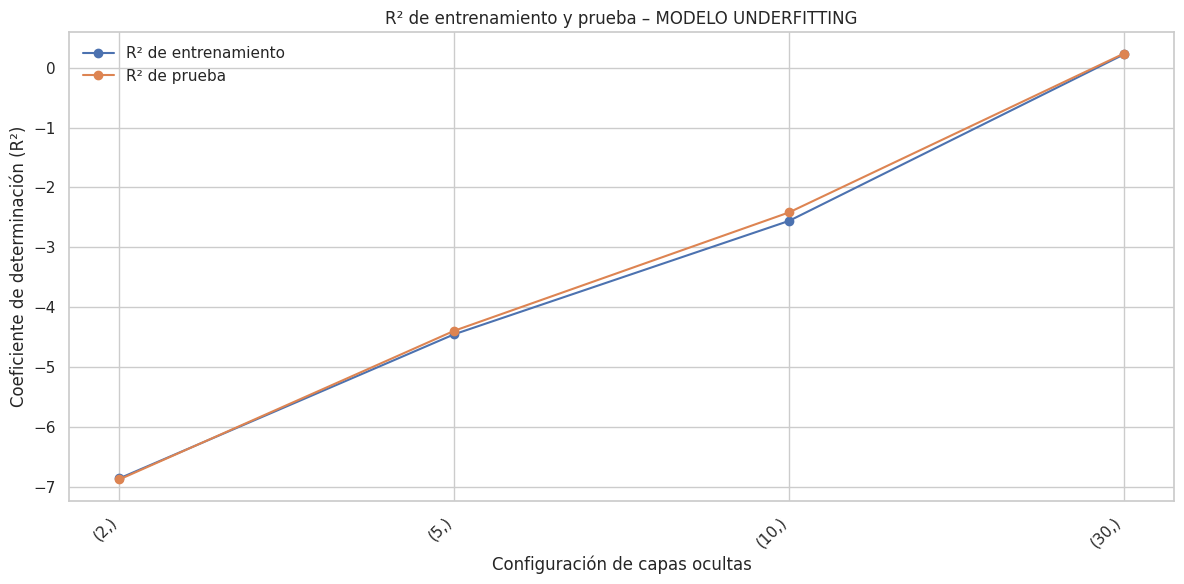

In [ ]:
# MODELO UNDERFITTING – R²
hidden_layers_list = [(2,), (5,), (10,), (30,)]
alpha_value = 0.01

r2_train_scores = []
r2_test_scores = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=500)
    r2_train_scores.append((hidden_layers, alpha_value, r2_train))
    r2_test_scores.append((hidden_layers, alpha_value, r2_test))
    print(f"UNDERFITTING - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - R² entrenamiento: {r2_train:.4f}")
    print(f"  - R² prueba: {r2_test:.4f}\n")

hidden_layer_labels = [f"{hl}" for hl, _, _ in r2_train_scores]
r2_train_values = [r2 for _, _, r2 in r2_train_scores]
r2_test_values = [r2 for _, _, r2 in r2_test_scores]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, r2_train_values, label='R² de entrenamiento', marker='o')
plt.plot(x, r2_test_values, label='R² de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Coeficiente de determinación (R²)')
plt.title('R² de entrenamiento y prueba – MODELO UNDERFITTING')
plt.legend()
plt.tight_layout()
plt.show()


Como se observa en el modelo underfitting, cuando la red posee pocas neuronas e iteraciones, los errores de entrenamiento y prueba resultan muy elevados, lo que demuestra que el modelo no aprendió lo suficiente y presenta una estructura demasiado simple.
En cuanto al coeficiente de determinación (R²), los valores comienzan muy por debajo de cero y aumentan ligeramente hasta alcanzar aproximadamente un 20%, lo que indica que el modelo logra explicar muy poca variabilidad de los datos y no consigue representar correctamente las relaciones entre las variables.

### 2.4 Estable

In [ ]:
# ESTABLE
mse_train_ok, mse_test_ok, r2_train_ok, r2_test_ok, mlp_ok = train_and_evaluate(hidden_layer_sizes=(200,150), alpha=0.001, max_iter=4000)
print("--- ESTABLE ---")
print(f"R² Train: {r2_train_ok:.4f} | R² Test: {r2_test_ok:.4f}")
print(f"MSE Train: {mse_train_ok:.4f} | MSE Test: {mse_test_ok:.4f}")

--- ESTABLE ---
R² Train: 0.8033 | R² Test: 0.7777
MSE Train: 37.0057 | MSE Test: 37.2904


#### Grafico MSE Estable

ESTABLE - hidden_layers=(50,), alpha=0.001
  - MSE entrenamiento: 53.7915
  - MSE prueba: 35.2374

ESTABLE - hidden_layers=(100,), alpha=0.001
  - MSE entrenamiento: 50.4422
  - MSE prueba: 35.1523

ESTABLE - hidden_layers=(150,), alpha=0.001
  - MSE entrenamiento: 48.8825
  - MSE prueba: 34.7621

ESTABLE - hidden_layers=(200,), alpha=0.001
  - MSE entrenamiento: 48.3002
  - MSE prueba: 34.5383

ESTABLE - hidden_layers=(200, 150), alpha=0.001
  - MSE entrenamiento: 37.0057
  - MSE prueba: 37.2904

ESTABLE - hidden_layers=(250, 200), alpha=0.001
  - MSE entrenamiento: 39.4208
  - MSE prueba: 35.3414



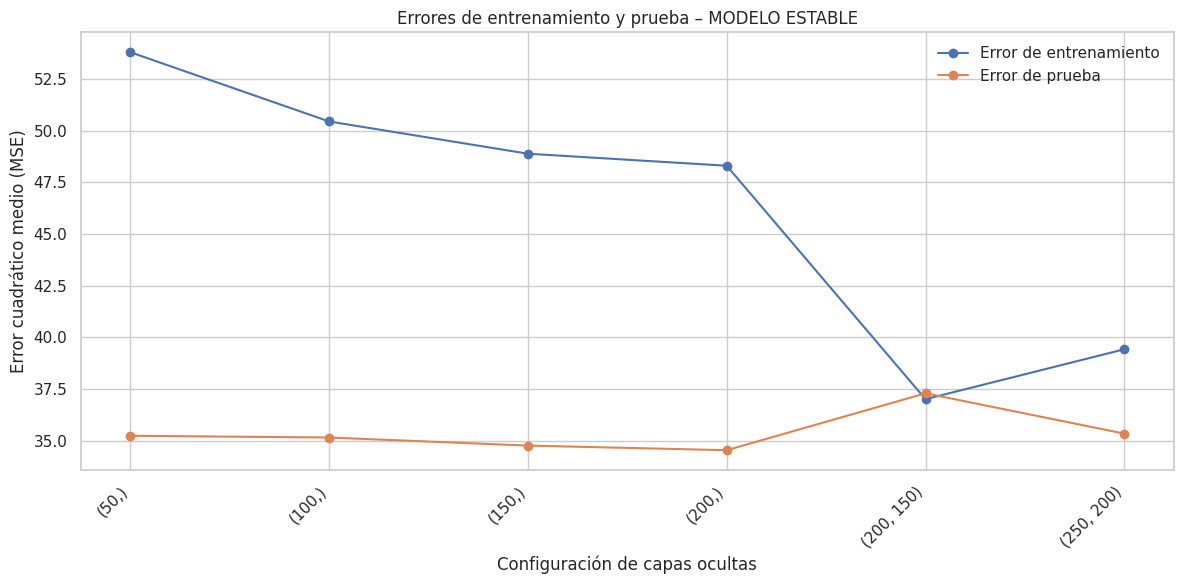

In [ ]:
# MODELO ESTABLE
hidden_layers_list = [(50,), (100,), (150,), (200,), (200,150), (250,200)]
alpha_value = 0.001

train_errors = []
test_errors = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=4000)
    train_errors.append((hidden_layers, alpha_value, mse_train))
    test_errors.append((hidden_layers, alpha_value, mse_test))
    print(f"ESTABLE - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - MSE entrenamiento: {mse_train:.4f}")
    print(f"  - MSE prueba: {mse_test:.4f}\n")

hidden_layer_labels = [f"{hl}" for hl, _, _ in train_errors]
train_error_values = [err for _, _, err in train_errors]
test_error_values = [err for _, _, err in test_errors]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, train_error_values, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Error cuadrático medio (MSE)')
plt.title('Errores de entrenamiento y prueba – MODELO ESTABLE')
plt.legend()
plt.tight_layout()
plt.show()


#### Grafico R² Estable

ESTABLE - hidden_layers=(50,), alpha=0.001
  - R² entrenamiento: 0.7140
  - R² prueba: 0.7900

ESTABLE - hidden_layers=(100,), alpha=0.001
  - R² entrenamiento: 0.7318
  - R² prueba: 0.7905

ESTABLE - hidden_layers=(150,), alpha=0.001
  - R² entrenamiento: 0.7401
  - R² prueba: 0.7928

ESTABLE - hidden_layers=(200,), alpha=0.001
  - R² entrenamiento: 0.7432
  - R² prueba: 0.7941

ESTABLE - hidden_layers=(200, 150), alpha=0.001
  - R² entrenamiento: 0.8033
  - R² prueba: 0.7777

ESTABLE - hidden_layers=(250, 200), alpha=0.001
  - R² entrenamiento: 0.7904
  - R² prueba: 0.7893



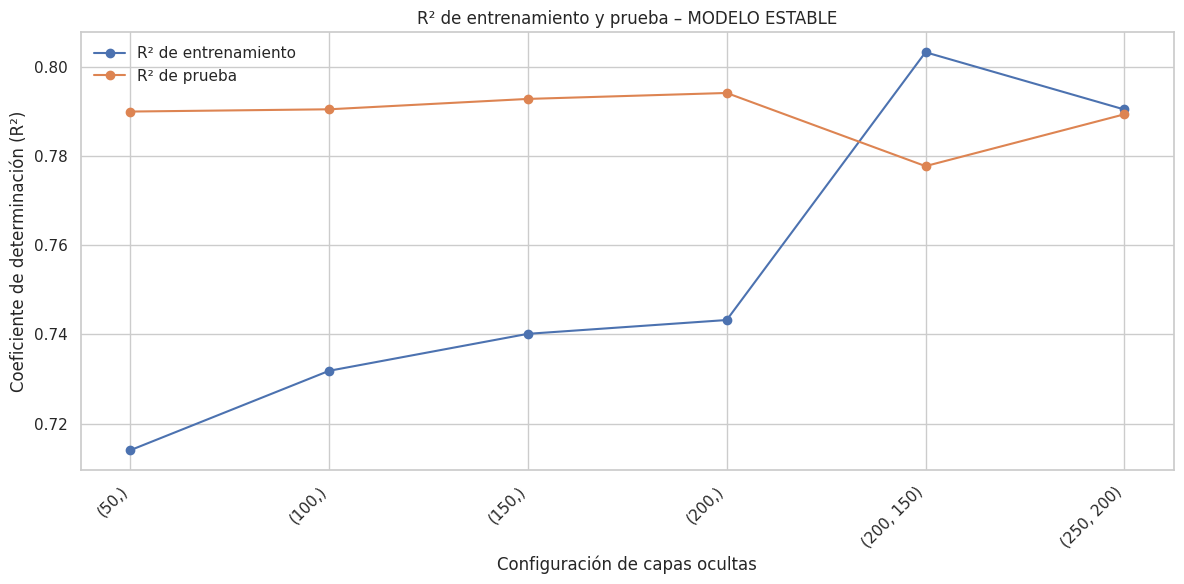

In [ ]:
# MODELO ESTABLE – R²
hidden_layers_list = [(50,), (100,), (150,), (200,), (200,150), (250,200)]
alpha_value = 0.001

r2_train_scores = []
r2_test_scores = []

for hidden_layers in hidden_layers_list:
    mse_train, mse_test, r2_train, r2_test, mlp_model = train_and_evaluate(hidden_layers, alpha=alpha_value, max_iter=4000)
    r2_train_scores.append((hidden_layers, alpha_value, r2_train))
    r2_test_scores.append((hidden_layers, alpha_value, r2_test))
    print(f"ESTABLE - hidden_layers={hidden_layers}, alpha={alpha_value}")
    print(f"  - R² entrenamiento: {r2_train:.4f}")
    print(f"  - R² prueba: {r2_test:.4f}\n")

hidden_layer_labels = [f"{hl}" for hl, _, _ in r2_train_scores]
r2_train_values = [r2 for _, _, r2 in r2_train_scores]
r2_test_values = [r2 for _, _, r2 in r2_test_scores]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels))
plt.plot(x, r2_train_values, label='R² de entrenamiento', marker='o')
plt.plot(x, r2_test_values, label='R² de prueba', marker='o')
plt.xticks(x, hidden_layer_labels, rotation=45, ha='right')
plt.xlabel('Configuración de capas ocultas')
plt.ylabel('Coeficiente de determinación (R²)')
plt.title('R² de entrenamiento y prueba – MODELO ESTABLE')
plt.legend()
plt.tight_layout()
plt.show()


Para el modelo estable se decidió aumentar ligeramente la complejidad, utilizando dos capas ocultas, la primera con 250 neuronas y la segunda con 200, junto con una regularización de 0.001.
En este modelo, los resultados de entrenamiento y de prueba son muy similares, con errores alrededor de 37.
En el gráfico se observa cómo ambas curvas de error se cruzan, generando un equilibrio adecuado entre aprendizaje y generalización.
Un mayor número de neuronas provocaría un overfitting, mientras que una cantidad menor podría generar underfitting.
En cuanto al coeficiente de determinación (R²), el valor de entrenamiento alcanza aproximadamente un 80%, mientras que el de prueba se sitúa en torno al 77%.
Esto demuestra que el modelo logra explicar gran parte de la variabilidad de los datos sin perder capacidad de generalización, manteniendo ambas curvas de R² cercanas y estables.

### Conclusiones:

Este modelo en general funciono mejor que el de regresion lineal que desarrole en el trabajo practico N° 1.

En el modelo lineal, el coeficiente de determinación (R²) fue de 54% en entrenamiento y 67% en prueba, mientras que con las redes neuronales, en el modelo estable, se logró un 80% en entrenamiento y un 77% en prueba, mostrando una mejora considerable.

También los errores MSE disminuyeron notablemente: en la regresión lineal fueron de 85 en entrenamiento y 54 en prueba, mientras que con redes neuronales bajaron a 37 tanto para el conjunto de datos de entrenamiento y prueba.
Esto demuestra que las redes neuronales no solo explican mejor la variabilidad de los datos, sino que también aprenden de una forma más eficiente.